# HW2

## Problem1. Make_Profile

Input = t DNA k-mers

Output = the profile (a t*k matrix)

Four parameters = k, t, the array of k-mers, and a boolean parameter *pseudocounts*

If *pseudocounts=true*, the function should generate the profile using pseudo-counts under *Laplace's Rule of Succession.* 

In [1]:
function Make_Profile(k, t, kmers, pseudocount)
    nts = ["A","C","G","T"]
    # Split the strings into the corresponding elements in a row
    kmers_str = split(kmers[1],"")
    for i in 2:t
        kmers_str = hcat(kmers_str, split(kmers[i],""))
    end
    kmers_str = permutedims(kmers_str)
    
    COUNT = Array{Float64}(undef,4,k)
    for i in 1:k
        for b in 1:4
            pos=kmers_str[:,i]
            COUNT[b,i] = sum([pos[j]==nts[b] for j=1:t])
        end
    end
    
    if pseudocount==true    # Laplace's Rule of Succession
        p_COUNT = COUNT + ones((4,k))
        return p_COUNT/(t+4)
    else
        return COUNT/t
    end
end
            

Make_Profile (generic function with 1 method)

## Problem 2.  

### 2-1. The probability Pr(kmer|Profile)

Input = a k-mer profile and a DNA sequence

Output = Pr(kmer|Profile) for every k-mer in the DNA sequence

In [2]:
function prob_kmer(profile, DNA)
    nts = "ACGT"
    n = length(DNA)
    k = length(profile[1,:])
    prob = ones(n-k+1)
    for i in 1:(n-k+1)
        for j in 1:k
            base_pos = findfirst(SubString(DNA,i+j-1,i+j-1), nts)
            prob[i] = prob[i] * profile[base_pos, j][1]
        end
    end
    return prob
end

prob_kmer (generic function with 1 method)

### 2-2. Get_Kmer

Input = k, profile, DNA_SEQUENCE, and the boolean parameter *deterministic*

Output = a k-mer formed by the profile-probable k-mers 
         and the position of k-mer in DNA_SEQUENCE.

If *deterministic=true*, the function should return the first kmer with the highest probability, o.w. the function should choose a kmer using the corresponding probabilities.

In [3]:
using Pkg
Pkg.add("StatsBase", io=devnull)
using StatsBase

function Get_Kmer(k, profile, DNA_SEQ, deterministic)
    n = length(DNA_SEQ)
    prob = prob_kmer(profile, DNA_SEQ)
    if deterministic == true
        kmer_pos = findfirst(x-> x == maximum(prob), prob)
    else
        kmer_pos = sample(collect(1:(n-k+1)), Weights(prob))
    end
    return DNA_SEQ[kmer_pos:(kmer_pos+k-1)]
end

Get_Kmer (generic function with 1 method)

## Problem 3. GibbsSampler

Input = DNA(t*n matrix), k(k-mer), t(number of DNA seqs), and N follwed by a collection of strings DNA

Output = The strings of Best Motifs resultging from running GibbsSampler(DNA,k,t,N) and the corresponding motif score. 

* Use pseudocounts.
* Read a test file called test.txt 

In [4]:
function GibbsSampler(DNA, k, t, N)
    n = length(DNA[1])
    
    # Randomly select k-mers in each string from DNA
    Motifs = copy(DNA)
    for i in 1:t
        rand_pos = sample(collect(1:n-k+1))
        Motifs[i] = SubString(DNA[i], rand_pos, rand_pos+k-1)
    end
    
    # BestMotifs 
    Best_Motifs = copy(Motifs)
    
    for j in 1:N
        i = sample(collect(1:t))
        motifs = copy(Motifs)
        motifs = deleteat!(motifs, i)
        profile = Make_Profile(k, t-1, motifs, true)        # pseudocount=true
        motif_i = Get_Kmer(k, profile, DNA[i], false)       # deterministic=false
        Motifs[i] = motif_i
        if SCORE(k,t,Motifs) < SCORE(k,t,Best_Motifs)
            Best_Motifs = copy(Motifs)
        end
    end
    
    return Best_Motifs

end

function SCORE(k, t, kmers)
    nts = ["A","C","G","T"]
    # Split the strings into the corresponding elements in a row
    kmers_str = split(kmers[1],"")
    for i in 2:t
        kmers_str = hcat(kmers_str, split(kmers[i],""))
    end
    kmers_str = permutedims(kmers_str)
    
    COUNT = Array{Float64}(undef,4,k)
    for i in 1:k
        for b in 1:4
            pos=kmers_str[:,i]
            COUNT[b,i] = sum([pos[j]==nts[b] for j=1:t])
        end
    end
    
    score = Array{Int64}(undef,k)
    for i in 1:k
        score[i] = t - maximum(COUNT[:,i])
    end
    return sum(score)
end

SCORE (generic function with 1 method)

### Result from the sample text file

In [22]:
# Read a text file
test = open("/Users/sangmi_jeong/Documents/julia/test.txt", "r")
lines = readlines(test)
close(test)

l = length(lines)
for i in 1:l
    lines[i] = strip(lines[i])
end

k = parse(Int64, match(r"^(\d+)", lines[1], 1)[1])
t = parse(Int64, match(r"(\d+)", lines[1], 2)[1])
N = parse(Int64, match(r"(\d+)$", lines[1])[1])
DNA = lines[2:l]


# Result
result = GibbsSampler(DNA, k, t, N)

# Data description
println("k=",k)
println("t=",t)
println("N=",N)
println("DNA sequences: ")
for l in 1:l-1
    println(" ", l,": ", DNA[l])
end
println("Best Motifs: ")
for l in 1:l-1
    println(" ", l,": ", result[l])
end

k=8
t=5
N=100
DNA sequences: 
 1: CGCCCCTCTCGGGGGTGTTCAGTAAACGGCCA
 2: GGGCGAGGTATGTGTAAGTGCCAAGGTGCCAG
 3: TAGTACCGAGACCGAAAGAAGTATACAGGCGT
 4: TAGATCAAGTTTCAGGTGCACGTCGGTGAACC
 5: AATCCACCAGCTCCACGTGCAATGTTGGCCTA
Best Motifs: 
 1: GTGTTCAG
 2: GTGCCAAG
 3: GTACCGAG
 4: GTTTCAGG
 5: GTGCAATG


## Problem 4. Generate artificial DNA sequences with implanted motifs

Input = t(# of DNA sequences), m(the motif to be implanted), l(length of each DNA sequence)

Output = [1] Artificial DNA sequences with implanted motifs and [2] the implanted motifs having m mutations

* Use a random number generator using 41% GC content.

In [6]:
function DNA_generator(t, m, l, mut)
    nts = ["A","C","G","T"]
    k = length(m)
    n_gc = Int64(round((l-k)*0.41))  # GC content 41%
    n_at = l-k-n_gc
    dna_seq = []
    motif_seq = []
    for i in 1:t
        motif = Mut_Motifs(m, mut)
        motif_seq = push!(motif_seq, motif)
        motif = split(motif,"")
        gc_nts = sample(["G","C"], n_gc, replace=true)
        at_nts = sample(["A","T"], n_at, replace=true)
        dna_nts = sample([gc_nts; at_nts], l-k, replace=false)
        pos = sample(collect(1:l-k+1))
        dna_seq = push!(dna_seq, join([dna_nts[1:pos-1]; motif; dna_nts[pos:end]]))
    end
    return [dna_seq, motif_seq]
end


function Mut_Motifs(m, mut)
    if mut==0
        return m
    else 
        nts = ["A","C","G","T"]
        n = length(m)
        j = sample(collect(1:n), mut, replace=false, ordered=true)
        m = split(m,"")
        for i in j
            base = copy(nts)
            m[i] = sample(deleteat!(base,base.==m[i]))
        end
        return join(m)
    end
end

Mut_Motifs (generic function with 1 method)

## Generate a consensus motif at random

In [7]:
function consensus_motif(length)
   return join(sample(["A","C","G","T"], length))
end

consensus_motif (generic function with 1 method)

## Benchmark the performance of your Gibbs sampler for 
    * different DNA sequence lengths, 
    * different numbers of DNA sequences, and
    * different motif lengths.
    
1.  Plot graphs for 
    * length of DNA sequences vs. correctly identified motifs (%)
    * length of DNA sequences vs. time and memory
    * length of motifs vs. correctly identified motifs (%)
    * length of motifs vs. time and memory
    * number of DNA sequences vs. correctly identified motifs(%)
    * number of DNA sequences vs. time and memory
2. Parameters
    * length of motifs(k): 10:2:20
    * number of mutations(mut): 0:1:5
    * length of DNA sequences(n): 50:50:500
    * number of DNA sequences(t): 10:5:100
    
### Packages for dataframes and plots

In [8]:
using Pkg
Pkg.add("DataFrames", io=devnull)
using DataFrames

using Pkg
Pkg.add("Plots", io=devnull)
Pkg.add("Measures", io=devnull)
using Plots, Measures

## 1) Length of DNA sequences vs. correctly identified motifs (%), time, and memory

In [23]:
# Setting
k = 14 # length of motif
t = 50 # number of DNA seqs
mut = 2 # number of mutations
rep = 200 # number of experiments
N = 500 # replications of Gibbs Sampler

l = [50:50:500;] # length of DNA sequences

result1 = Array{Float64}(undef,length(l),3)

for i in 1:length(l)
    id_motifs = Array{Float64}(undef,rep)
    time = Array{Float64}(undef,rep)
    memory = Array{Float64}(undef,rep)
    for j in 1:rep
        consensus = consensus_motif(k)
        seqs = DNA_generator(t, consensus, l[i], mut)
        DNA_seqs = string.(seqs[1])
        motif_seqs = string.(seqs[2])
        pred = @timed GibbsSampler(DNA_seqs, k, t, N)
        pred_motifs = string.(pred.value)
        id_motifs[j] = sum([pred_motifs[q] in motif_seqs for q in 1:t])/t
        time[j] = pred.time
        memory[j] = pred.bytes
    end
    result1[i,1] = sum(id_motifs)/rep*100
    result1[i,2] = mean(time)
    result1[i,3] = mean(memory)/10^9    
end

In [24]:
df1 = DataFrame(length_DNA=l, Id_motifs=result1[:,1], Time=result1[:,2], MemoryGB=result1[:,3])

Row,length_DNA,Id_motifs,Time,MemoryGB
,Int64,Float64,Float64,Float64
1,50,19.03,0.65446,1.0824
2,100,15.46,0.700558,1.15007
3,150,4.95,0.755026,1.21764
4,200,5.62,0.788359,1.28532
5,250,2.59,0.847834,1.35294
6,300,1.69,0.928958,1.42056
7,350,3.44,1.07765,1.48823
8,400,1.06,1.1589,1.55584
9,450,0.96,1.18858,1.62344


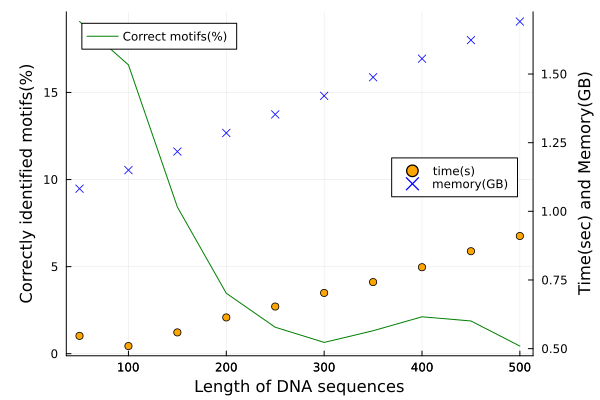

In [11]:
x = l
y = result1[:,1]
z = result1[:,2]
q = result1[:,3]

gr()
plot1 = plot(x, y, color=:green, label="Correct motifs(%)", legend=:topleft,
    ylabel="Correctly identified motifs(%)",
    left_margin = 5Plots.mm, right_margin = 15Plots.mm)
xlabel!("Length of DNA sequences")
axis2=twinx()
scatter!(axis2, x, z, color=:orange, label="time(s)")
scatter!(axis2, x, q, color=:blue, markershape=:x, label="memory(GB)", 
    ylabel="Time(sec) and Memory(GB)", legend=:right)
display(plot1)
savefig("LengthDNA.pdf")

**(Result)** The graph shows the correctly identified motifs(%), the running time(seconds), and the memory(GB) corresponding to the differnt lengths of DNA sequences.

The other parameters were set as :
    * length of motif :         k = 14
    * number of DNA seqs :      t = 50 
    * number of mutations :     mut = 2
    * number of experiments :   rep = 200
    * replications of Gibbs Sampler :   N = 500
    
** As the length of DNA sequences increases, **
    1. the percentage of correctly identified motifs(%) drops for long DNA sequences greater than 100 nucleotides.
       So, when the length of DNA sequences is smaller, the GibbsSampler predicts the motifs better.
    2. the running time gradually increases.
    3. the memory requires more space at a linear growth rate.

## 2) Length of motifs vs. correctly identified motifs (%), time, and memory with different numbers of mutations in the motifs

In [34]:
# Setting
l = 200 # length of DNA sequences
t = 50 # number of DNA seqs
rep = 200 # number of experiments
N = 500 # replications of Gibbs Sampler

k = [10:2:20;] # length of motif
mut = [0:1:5;] # number of mutations

result2 = Array{Float64}(undef,length(k),3*length(mut))

for i in 1:length(k)
    for p in 1:length(mut)
        id_motifs = Array{Float64}(undef,rep)
        time = Array{Float64}(undef,rep)
        memory = Array{Float64}(undef,rep)
        for j in 1:rep
            consensus = consensus_motif(k[i])
            seqs = DNA_generator(t, consensus, l, mut[p])
            DNA_seqs = string.(seqs[1]); #println(DNA_seqs[1], "\n")
            motif_seqs = string.(seqs[2]); #println(motif_seqs[1])
            pred = @timed GibbsSampler(DNA_seqs, k[i], t, N); #println("pred",pred.value)
            pred_motifs = string.(pred.value)
            id_motifs[j] = sum([pred_motifs[q] in motif_seqs for q in 1:t])/t
            time[j] = pred.time
            memory[j] = pred.bytes
        end
        result2[i,p*3-2] = sum(id_motifs)/rep*100
        result2[i,p*3-1] = mean(time)
        result2[i,p*3] = mean(memory)/10^9
    end
end

In [77]:
result2

6×18 Matrix{Float64}:
 6.8   0.565985  0.956012  3.89  …  0.956007  0.21  0.613707  0.956007
 6.02  0.662556  1.12065   4.87     1.12064   0.25  1.32039   1.12064
 6.97  1.15447   1.28533   3.99     1.28532   0.17  0.794774  1.28532
 1.5   0.998091  1.4465    6.0      1.44649   0.15  1.21468   1.44649
 8.99  1.12171   1.61052   8.39     1.61051   1.47  1.04784   1.61051
 7.02  1.17165   1.77191   8.37  …  1.77191   1.19  1.30953   1.7719

The number of mutations is 0


Row,length_Motif,Id_motifs,Time,MemoryGB
,Int64,Float64,Float64,Float64
1,10,6.8,0.565985,0.956012
2,12,6.02,0.662556,1.12065
3,14,6.97,1.15447,1.28533
4,16,1.5,0.998091,1.4465
5,18,8.99,1.12171,1.61052
6,20,7.02,1.17165,1.77191


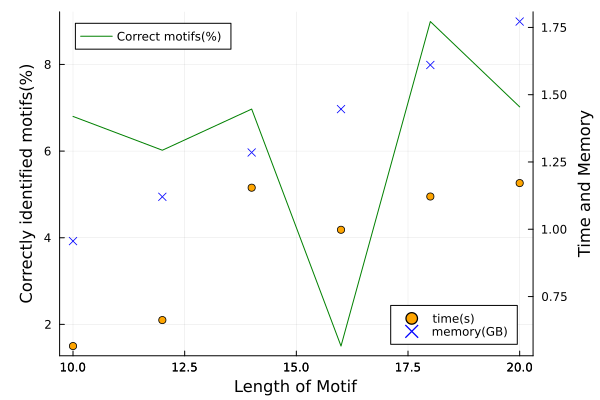

The number of mutations is 1


Row,length_Motif,Id_motifs,Time,MemoryGB
,Int64,Float64,Float64,Float64
1,10,3.89,0.585342,0.95601
2,12,4.87,0.713162,1.12064
3,14,3.99,0.892084,1.28533
4,16,6.0,0.959342,1.4465
5,18,8.39,1.07836,1.61052
6,20,8.37,1.12651,1.77191


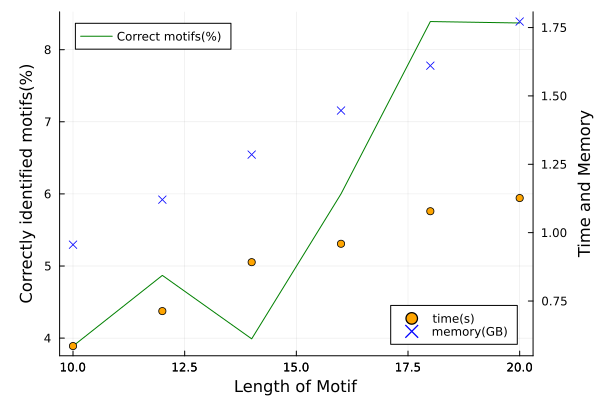

The number of mutations is 2


Row,length_Motif,Id_motifs,Time,MemoryGB
,Int64,Float64,Float64,Float64
1,10,0.3,0.573852,0.956008
2,12,2.06,0.856805,1.12064
3,14,4.93,1.0488,1.28532
4,16,4.51,0.93792,1.4465
5,18,4.52,1.04653,1.61052
6,20,4.45,1.16722,1.77191


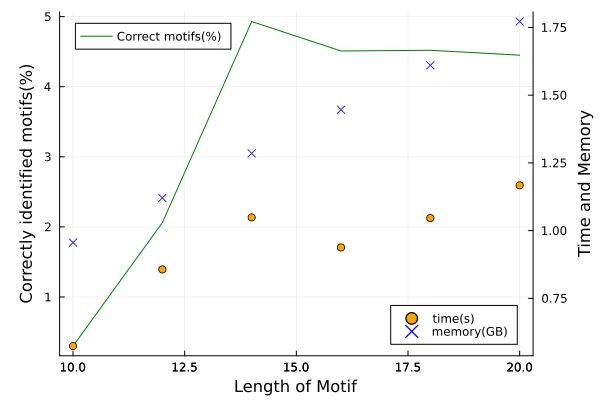

The number of mutations is 3


Row,length_Motif,Id_motifs,Time,MemoryGB
,Int64,Float64,Float64,Float64
1,10,0.25,0.566625,0.956007
2,12,0.27,0.897818,1.12064
3,14,0.55,0.792395,1.28532
4,16,3.56,0.942981,1.4465
5,18,2.54,1.05517,1.61051
6,20,3.6,1.1656,1.77191


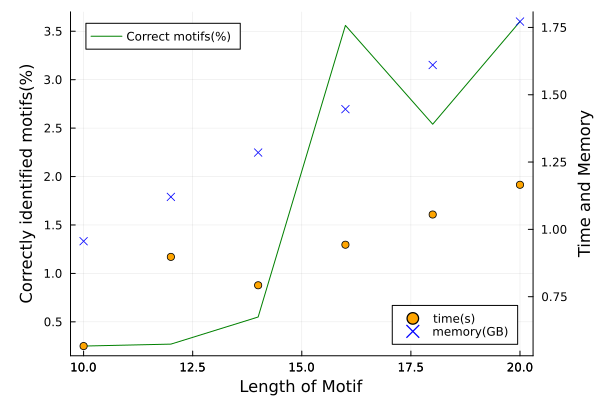

The number of mutations is 4


Row,length_Motif,Id_motifs,Time,MemoryGB
,Int64,Float64,Float64,Float64
1,10,0.29,0.584029,0.956007
2,12,0.21,1.58335,1.12064
3,14,0.19,0.808271,1.28532
4,16,0.87,0.973232,1.44649
5,18,2.49,1.15885,1.61051
6,20,4.86,1.17448,1.77191


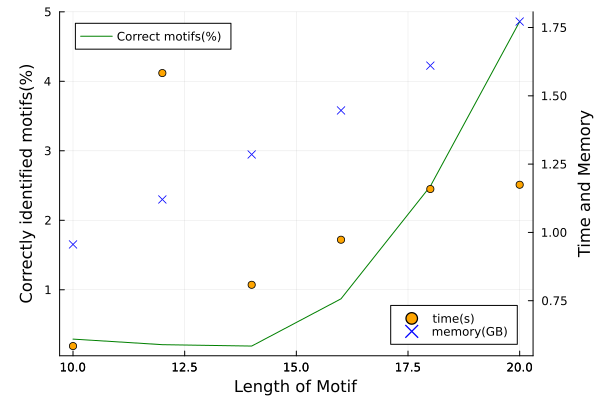

The number of mutations is 5


Row,length_Motif,Id_motifs,Time,MemoryGB
,Int64,Float64,Float64,Float64
1,10,0.21,0.613707,0.956007
2,12,0.25,1.32039,1.12064
3,14,0.17,0.794774,1.28532
4,16,0.15,1.21468,1.44649
5,18,1.47,1.04784,1.61051
6,20,1.19,1.30953,1.7719


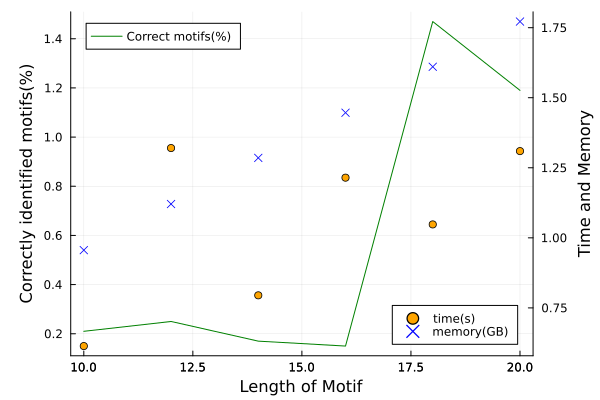

In [79]:
function graph(p)
    x = k
    y = result2[:,p*3-2]
    z = result2[:,p*3-1]
    q = result2[:,p*3]

    gr()
    plot2 = plot(x, y, color=:green, label="Correct motifs(%)", legend=:topleft,
        ylabel="Correctly identified motifs(%)",
        left_margin = 5Plots.mm, right_margin = 15Plots.mm)
    xlabel!("Length of Motif")
    axis2=twinx()
    scatter!(axis2, x, z, color=:orange, label="time(s)")
    scatter!(axis2, x, q, color=:blue, markershape=:x, label="memory(GB)", 
        ylabel="Time and Memory", legend=:bottomright)
    return(plot2)
end

for p in 1:length(mut)
    println("The number of mutations is ", mut[p])
    df2= DataFrame(length_Motif=k, Id_motifs=result2[:,p*3-2], Time=result2[:,p*3-1], MemoryGB=result2[:,p*3])
    display(df2)
    plot = graph(p)
    display(plot)
end

**(Result)** The graph shows the correctly identified motifs(%), the running time(seconds), and the memory(GB) corresponding to the differnt lengths of motif.

The other parameters were set as :
    * length of DNA sequences:  l = 200
    * number of DNA seqs :      t = 50 
    * number of experiments :   rep = 200
    * replications of Gibbs Sampler :   N = 500
    
** As the length of motifs increases, **
    1. the percentage of correctly identified motifs(%) tends to increase. When the number of mutation is bigger,
       the correct motifs increases at an exponential growth rate with longer motifs.
           * As the number of mutations increases, the percentage of correctly identified motifs decreases
             overall. Interestingly, when there is no mutation, the percentage of correctly 
             identified motifs does not necessarily depend on the length of motif because the GibbsSampler 
             predicts well in the range of 10 and 20 motif length.
    2. the running time increases. However, when the number of mutations increases, the running time seem to 
       fluctuate more.
    3. the memory steadily increases. Also, the memory doesn't depend on the number of mutations.

## 3) Number of DNA sequences vs. correctly identified motifs (%), time, and memory

In [15]:
# Setting
l = 200 # length of DNA sequences
k = 14 # length of motif
mut = 2 # number of mutations
rep = 200 # number of experiments
N = 500 # replications of Gibbs Sampler

t = [10:5:100;] # number of DNA seqs

result3 = Array{Float64}(undef,length(t),3)

for i in 1:length(t)
    id_motifs = Array{Float64}(undef,rep)
    time = Array{Float64}(undef,rep)
    memory = Array{Float64}(undef,rep)
    for j in 1:rep
        consensus = consensus_motif(k)
        seqs = DNA_generator(t[i], consensus, l, mut)
        DNA_seqs = string.(seqs[1]); #println(DNA_seqs[1], "\n")
        motif_seqs = string.(seqs[2]); #println(motif_seqs[1])
        pred = @timed GibbsSampler(DNA_seqs, k, t[i], N); #println("pred",pred.value)
        pred_motifs = string.(pred.value)
        id_motifs[j] = sum([pred_motifs[q] in motif_seqs for q in 1:t[i]])/t[i]
        time[j] = pred.time
        memory[j] = pred.bytes
    end
    result3[i,1] = sum(id_motifs)/rep*100
    result3[i,2] = mean(time)
    result3[i,3] = mean(memory)/10^9  
end

In [16]:
df3 = DataFrame(Numter_DNAs=t, Id_motifs=result3[:,1], Time=result3[:,2], MemoryGB=result3[:,3])

Row,Numter_DNAs,Id_motifs,Time,MemoryGB
,Int64,Float64,Float64,Float64
1,10,5.9,0.251174,0.365275
2,15,10.4,0.28885,0.436526
3,20,6.0,0.311436,0.519457
4,25,5.0,0.349299,0.615093
5,30,3.51667,0.396257,0.724648
6,35,3.71429,0.454894,0.842717
7,40,4.2375,0.505203,0.979194
8,45,3.0,0.561592,1.12347
9,50,5.38,0.629238,1.28532


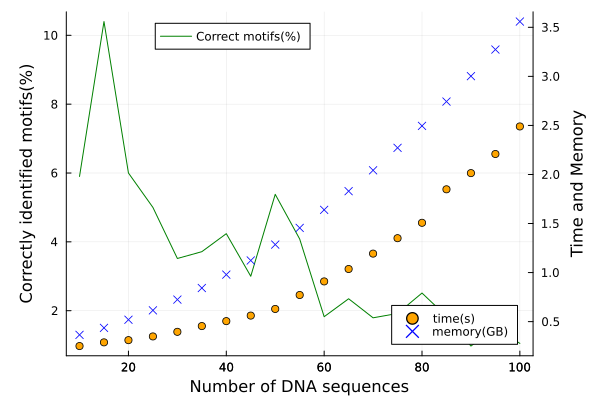

In [17]:
x = t
y = result3[:,1]
z = result3[:,2]
q = result3[:,3]

gr()
plot3 = plot(x, y, color=:green, label="Correct motifs(%)", legend=:top,
    ylabel="Correctly identified motifs(%)",
    left_margin = 5Plots.mm, right_margin = 15Plots.mm)
xlabel!("Number of DNA sequences")
axis2=twinx()
scatter!(axis2, x, z, color=:orange, label="time(s)")
scatter!(axis2, x, q, color=:blue, markershape=:x, label="memory(GB)", 
    ylabel="Time and Memory", legend=:bottomright)
display(plot3)
savefig("NumberDNAs.pdf")

**(Result)** The graph shows the correctly identified motifs(%), the running time(seconds), and the memory(GB) corresponding to the different numbers of DNA sequences.

The other parameters were set as :
    * length of DNA sequences:  l = 200
    * length of motif:          k = 14 
    * number of mutations :     mut = 2
    * number of experiments :   rep = 200
    * replications of Gibbs Sampler :   N = 500
    
** As the number of DNA sequences increases, **
    1. the percentage of correctly identified motifs(%) tends to decrease despite some peaks.
    2. the running time increases.
    3. the memory consumes more space at a polynomial growth rate beause the number of predicted 
       motifs also increases.